In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
import yfinance as yf # Import yfinance

plt.style.use('fivethirtyeight')

In [ ]:
training_stocks = {
    'AAPL': {'sector': 'Technology', 'start': '2010-01-04', 'end': '2020-12-31'},
    'MSFT': {'sector': 'Technology', 'start': '2010-01-04', 'end': '2020-12-31'},
    'JPM': {'sector': 'Financial', 'start': '2010-01-04', 'end': '2020-12-31'},
    'JNJ': {'sector': 'Healthcare', 'start': '2010-01-04', 'end': '2020-12-31'},
    'XOM': {'sector': 'Energy', 'start': '2010-01-04', 'end': '2020-12-31'}
}

In [ ]:
# Dictionary to store all stock data
stock_data = {}

# Fetch data for each stock
for stock, info in training_stocks.items():
    print(f"Fetching data for {stock}...")

    # Download stock data
    ticker = yf.download(stock, start=info['start'], end=info['end'])

    # Add sector information
    ticker['Sector'] = info['sector']

    # Store in dictionary
    stock_data[stock] = ticker

    print(f"✅ {stock} data fetched successfully")
    print(f"   Shape: {ticker.shape}")
    print(f"   Date range: {ticker.index[0].date()} to {ticker.index[-1].date()}")
    print("-" * 50)

/tmp/ipython-input-3164942415.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker = yf.download(stock, start=info['start'], end=info['end'])
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3164942415.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker = yf.download(stock, start=info['start'], end=info['end'])
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3164942415.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker = yf.download(stock, start=info['start'], end=info['end'])
[*********************100%***********************]  1 of 1 completed

Fetching data for AAPL...
✅ AAPL data fetched successfully
   Shape: (2768, 6)
   Date range: 2010-01-04 to 2020-12-30
--------------------------------------------------
Fetching data for MSFT...
✅ MSFT data fetched successfully
   Shape: (2768, 6)
   Date range: 2010-01-04 to 2020-12-30
--------------------------------------------------
Fetching data for JPM...
✅ JPM data fetched successfully
   Shape: (2768, 6)
   Date range: 2010-01-04 to 2020-12-30
--------------------------------------------------
Fetching data for JNJ...



/tmp/ipython-input-3164942415.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker = yf.download(stock, start=info['start'], end=info['end'])
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3164942415.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker = yf.download(stock, start=info['start'], end=info['end'])
[*********************100%***********************]  1 of 1 completed


✅ JNJ data fetched successfully
   Shape: (2768, 6)
   Date range: 2010-01-04 to 2020-12-30
--------------------------------------------------
Fetching data for XOM...
✅ XOM data fetched successfully
   Shape: (2768, 6)
   Date range: 2010-01-04 to 2020-12-30
--------------------------------------------------


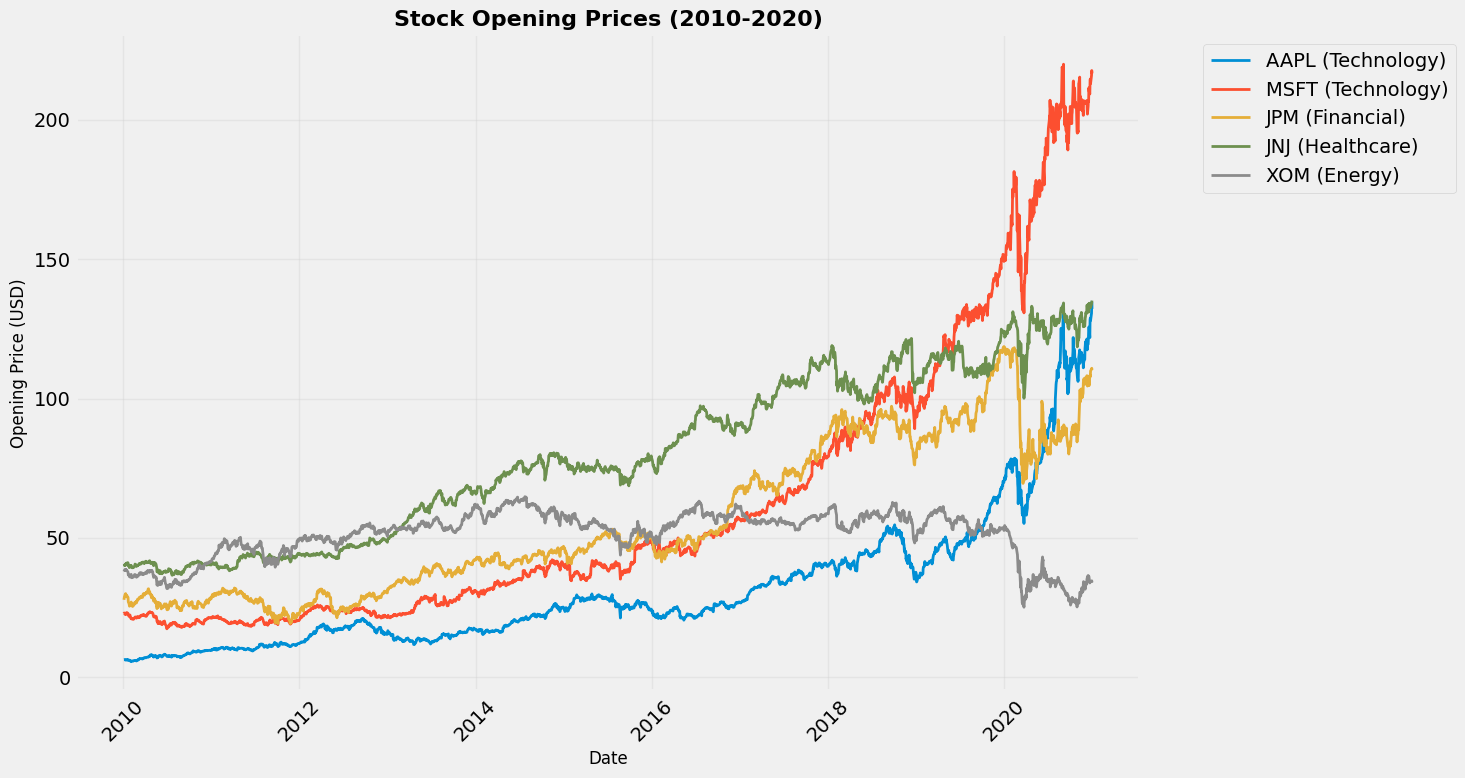

In [ ]:
# Plot 1: Opening Prices for all stocks
plt.figure(figsize=(15, 8))

for stock, data in stock_data.items():
    plt.plot(data.index, data['Open'], label=f"{stock} ({training_stocks[stock]['sector']})", linewidth=2)

plt.title('Stock Opening Prices (2010-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Opening Price (USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

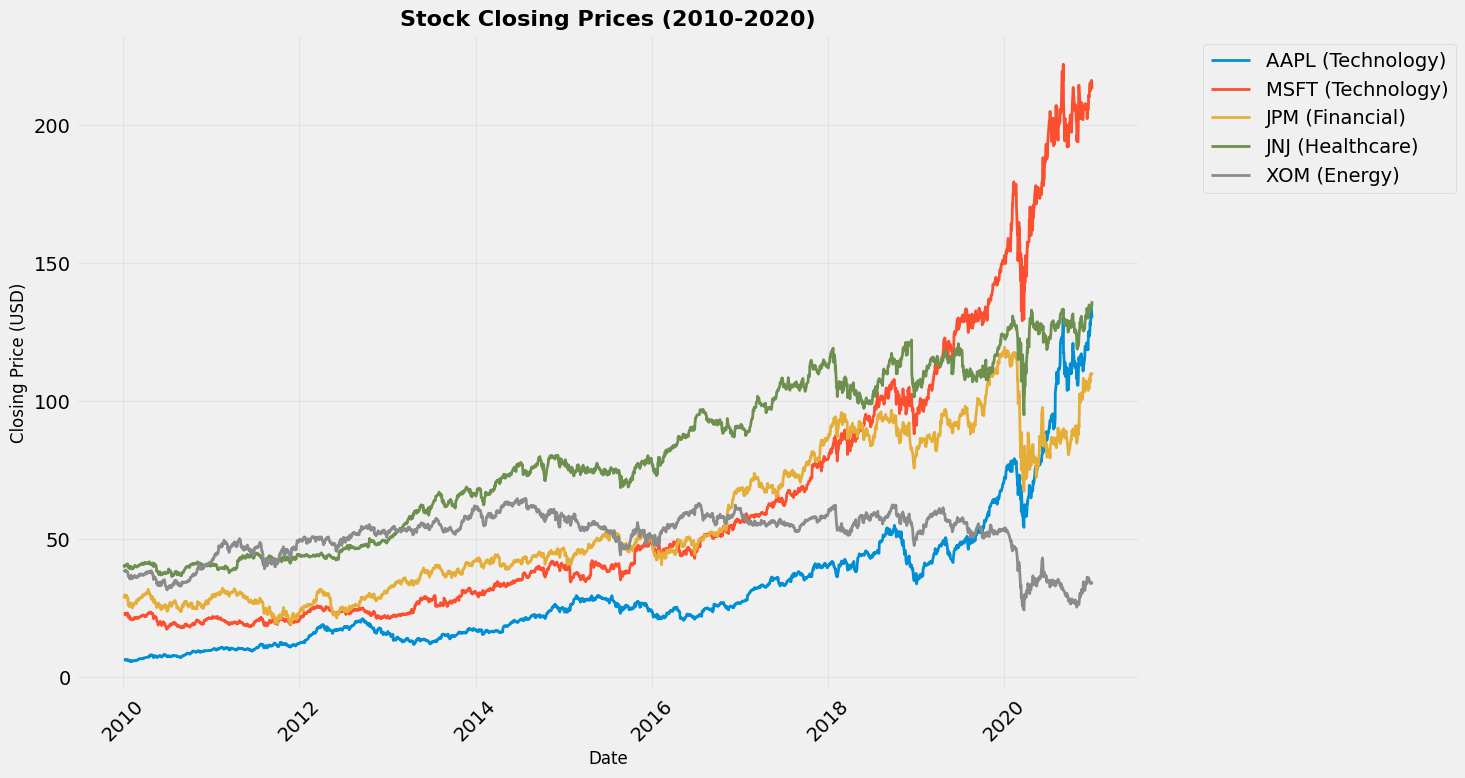

In [ ]:
# Plot 2: Closing Prices for all stocks
plt.figure(figsize=(15, 8))

for stock, data in stock_data.items():
    plt.plot(data.index, data['Close'], label=f"{stock} ({training_stocks[stock]['sector']})", linewidth=2)

plt.title('Stock Closing Prices (2010-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

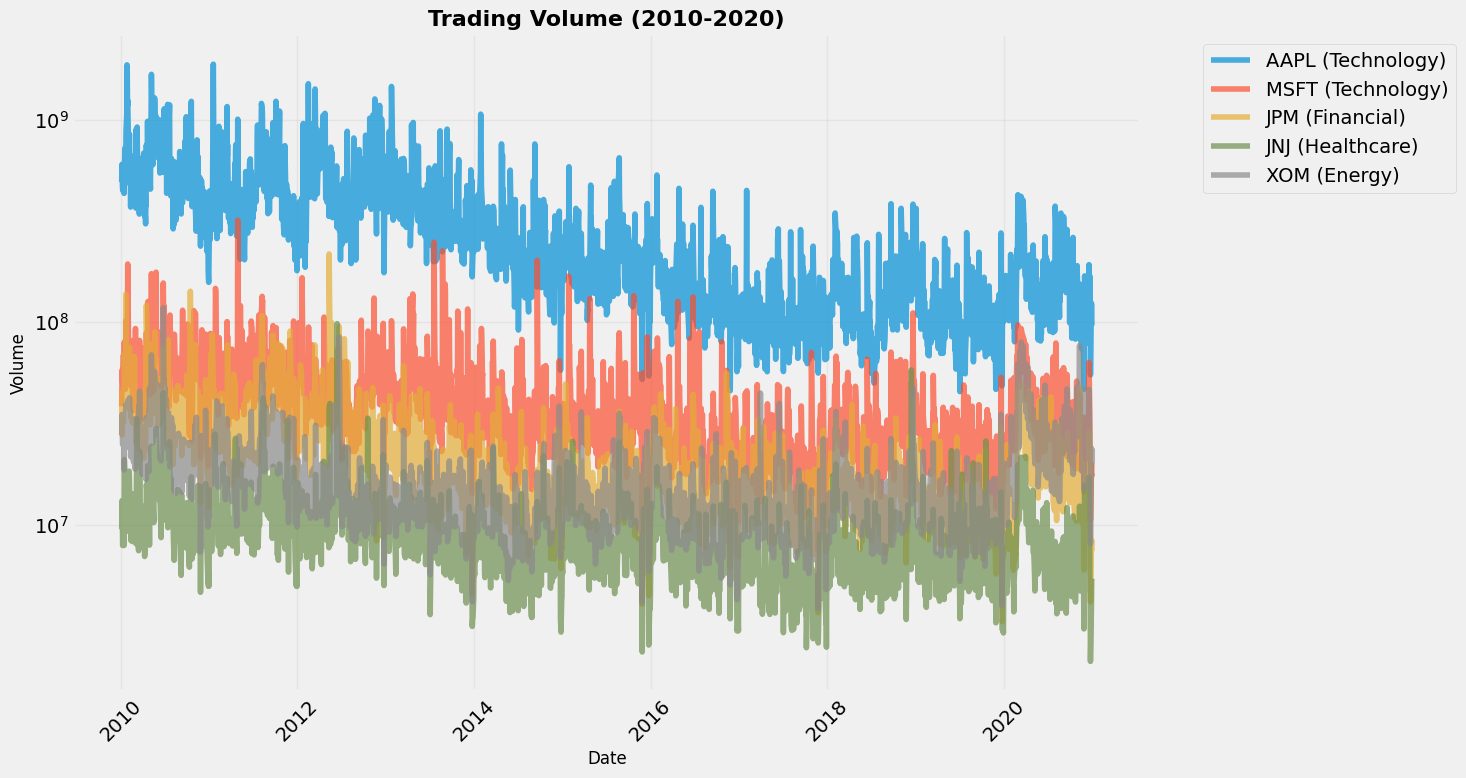

In [ ]:
# Plot 3: Trading Volume for all stocks
plt.figure(figsize=(15, 8))

for stock, data in stock_data.items():
    plt.plot(data.index, data['Volume'], label=f"{stock} ({training_stocks[stock]['sector']})", alpha=0.7)

plt.title('Trading Volume (2010-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale for better visualization
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

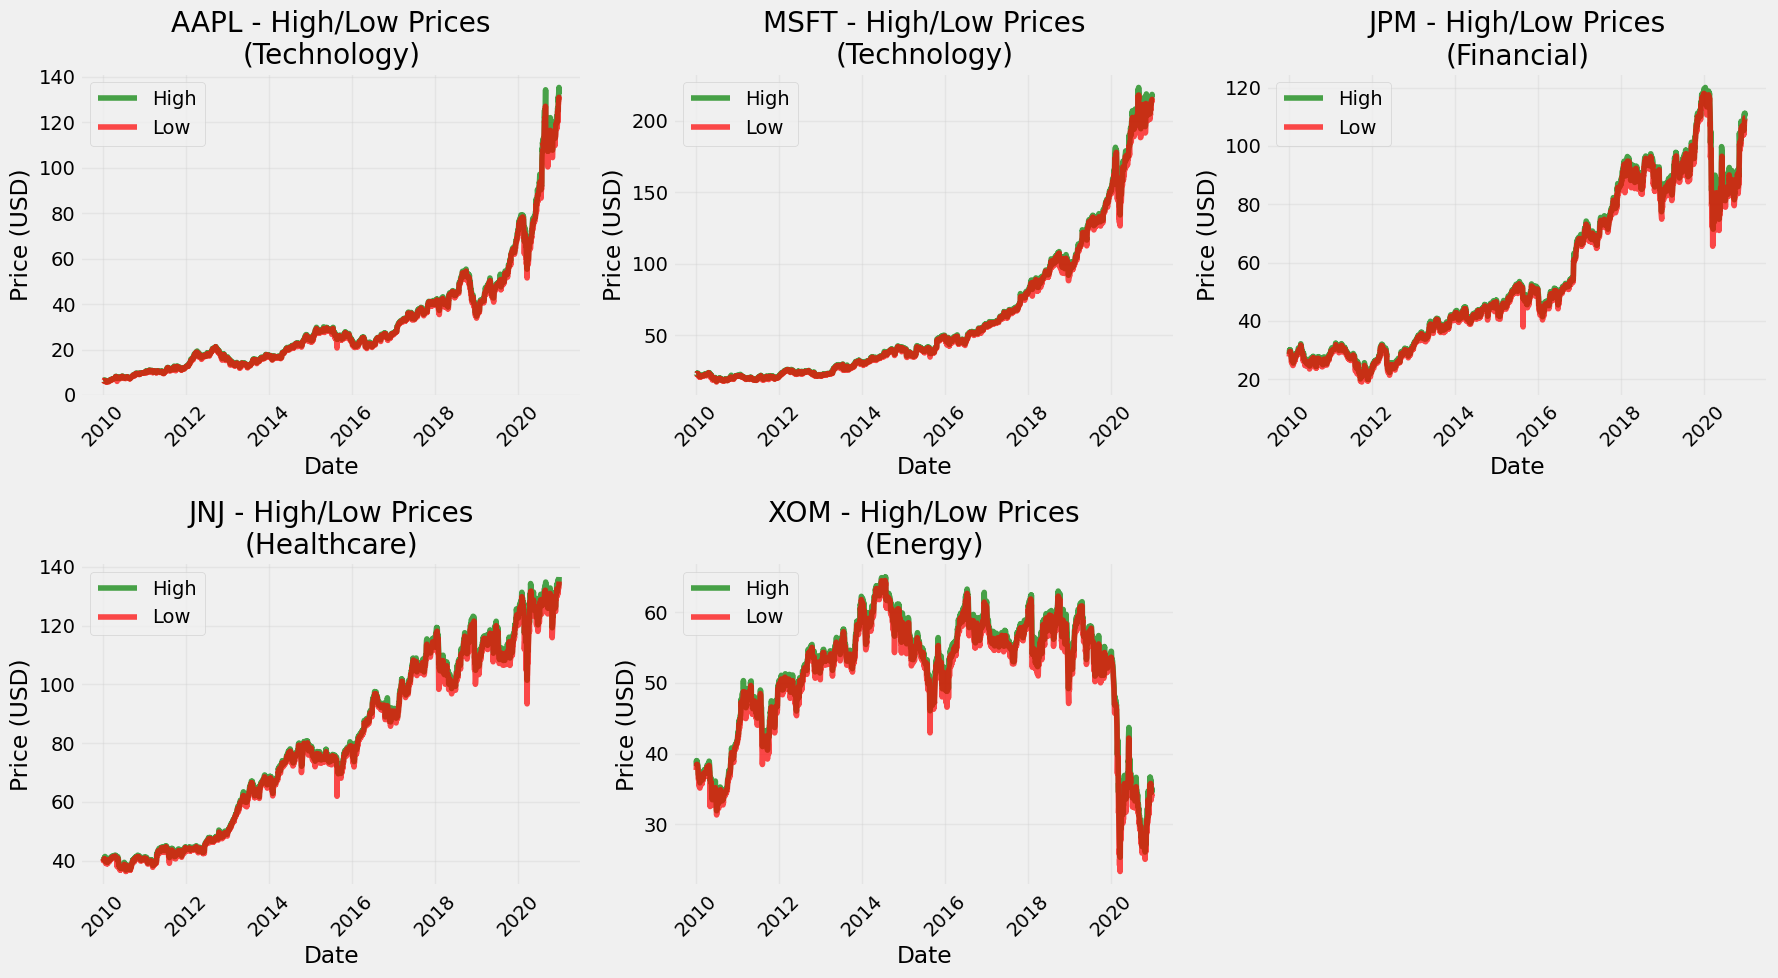

In [ ]:
# Plot 4: High and Low prices for each stock (subplots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (stock, data) in enumerate(stock_data.items()):
    if i < len(axes):
        axes[i].plot(data.index, data['High'], label='High', color='green', alpha=0.7)
        axes[i].plot(data.index, data['Low'], label='Low', color='red', alpha=0.7)
        axes[i].set_title(f'{stock} - High/Low Prices\n({training_stocks[stock]["sector"]})')
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel('Price (USD)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot if any
if len(stock_data) < len(axes):
    for j in range(len(stock_data), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# After plotting, prepare data for LSTM
print("STARTING LSTM PREPARATION")
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = ['Open', 'High', 'Low', 'Close', 'Volume']
lookback = 60
prepared_data = {}

STARTING LSTM PREPARATION


In [ ]:
def create_splits(data, train_ratio=0.7, val_ratio=0.15):
    total_size = len(data)
    train_end = int(total_size * train_ratio)
    val_end = train_end + int(total_size * val_ratio)

    return {
        'train': data.iloc[:train_end],
        'val': data.iloc[train_end:val_end],
        'test': data.iloc[val_end:]
    }

stock_splits = {}
for stock, data in stock_data.items():
    stock_splits[stock] = create_splits(data)
    print(f"{stock}: Train({len(stock_splits[stock]['train'])}), Val({len(stock_splits[stock]['val'])}), Test({len(stock_splits[stock]['test'])})")

AAPL: Train(1937), Val(415), Test(416)
MSFT: Train(1937), Val(415), Test(416)
JPM: Train(1937), Val(415), Test(416)
JNJ: Train(1937), Val(415), Test(416)
XOM: Train(1937), Val(415), Test(416)


In [ ]:
def create_sequences(data, lookback, features):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 3])  # Close price at index 3
    return np.array(X), np.array(y)

for stock, splits in stock_splits.items():
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit scaler on training data only
    train_scaled = scaler.fit_transform(splits['train'][features])
    val_scaled = scaler.transform(splits['val'][features])
    test_scaled = scaler.transform(splits['test'][features])

    # Create sequences
    X_train, y_train = create_sequences(train_scaled, lookback, features)
    X_val, y_val = create_sequences(val_scaled, lookback, features)
    X_test, y_test = create_sequences(test_scaled, lookback, features)

    # Reshape for LSTM
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], len(features)))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], len(features)))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], len(features)))

    prepared_data[stock] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler
    }
    print(f"✅ {stock} prepared: {X_train.shape}")

✅ AAPL prepared: (1877, 60, 5)
✅ MSFT prepared: (1877, 60, 5)
✅ JPM prepared: (1877, 60, 5)
✅ JNJ prepared: (1877, 60, 5)
✅ XOM prepared: (1877, 60, 5)


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

models = {}
for stock, data in prepared_data.items():
    input_shape = (data['X_train'].shape[1], data['X_train'].shape[2])
    models[stock] = create_lstm_model(input_shape)
    print(f"✅ {stock} model created")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ AAPL model created
✅ MSFT model created
✅ JPM model created
✅ JNJ model created
✅ XOM model created


In [38]:
print("TRAINING MODELS...")
training_history = {}

for stock, model in models.items():
    data = prepared_data[stock]

    history = model.fit(
        data['X_train'], data['y_train'],
        epochs=50,
        batch_size=32,
        validation_data=(data['X_val'], data['y_val']),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=1
    )

    training_history[stock] = history
    print(f"✅ {stock} training completed")

TRAINING MODELS...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0488 - val_loss: 0.0389
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 0.0036 - val_loss: 0.0133
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0030 - val_loss: 0.0186
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 0.0037 - val_loss: 0.0278
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0034 - val_loss: 0.0188
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 0.0027 - val_loss: 0.0060
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 0.0027 - val_loss: 0.0081
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 0.0022 - val_loss: 0.0135
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0030 - val_loss: 0.0204
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - loss: 0.0026 - val_loss: 0.0128
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0021 - val_loss: 0.0077
Epoch 12/50
59/59 ━━━━━━━━━━━━━━

In [44]:
# Fix the inverse transformation issue
print("FIXING PREDICTION VALUES...")

def inverse_transform_predictions(scaler, predictions, features, target_index=3):
    """
    Properly inverse transform predictions
    """
    # Create a dummy array with same shape as original features
    dummy = np.zeros((len(predictions), len(features)))

    # Put predictions in the correct column (Close price position)
    dummy[:, target_index] = predictions.flatten()

    # Inverse transform
    inverted = scaler.inverse_transform(dummy)

    # Extract only the Close price column
    return inverted[:, target_index]

# Recalculate predictions with proper inverse transform
fixed_predictions = {}

for stock, model in models.items():
    data = prepared_data[stock]

    # Predict on test set
    test_predict_scaled = model.predict(data['X_test'])

    # Proper inverse transformation
    test_predict = inverse_transform_predictions(data['scaler'], test_predict_scaled, features)
    test_actual = inverse_transform_predictions(data['scaler'], data['y_test'], features)

    fixed_predictions[stock] = {
        'predicted': test_predict,
        'actual': test_actual
    }

    print(f"✅ {stock} fixed - Actual range: ${test_actual.min():.2f} to ${test_actual.max():.2f}")

FIXING PREDICTION VALUES...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
✅ AAPL fixed - Actual range: $46.38 to $133.19
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
✅ MSFT fixed - Actual range: $124.92 to $222.11
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
✅ JPM fixed - Actual range: $67.41 to $119.57
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
✅ JNJ fixed - Actual range: $95.07 to $136.25
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
✅ XOM fixed - Actual range: $24.36 to $55.62


In [45]:
print("\nFIXED MODEL EVALUATION:")
print("=" * 50)

for stock, pred in fixed_predictions.items():
    mae = mean_absolute_error(pred['actual'], pred['predicted'])
    mse = mean_squared_error(pred['actual'], pred['predicted'])
    rmse = math.sqrt(mse)

    # Calculate accuracy metrics
    mape = np.mean(np.abs((pred['actual'] - pred['predicted']) / pred['actual'])) * 100

    print(f"\n{stock}:")
    print(f"  MAE: ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  Last Actual Price: ${pred['actual'][-1]:.2f}")
    print(f"  Last Predicted Price: ${pred['predicted'][-1]:.2f}")
    print(f"  Price Range: ${pred['actual'].min():.2f} - ${pred['actual'].max():.2f}")


FIXED MODEL EVALUATION:

AAPL:
  MAE: $26.10
  RMSE: $33.86
  MAPE: 26.82%
  Last Actual Price: $130.30
  Last Predicted Price: $59.09
  Price Range: $46.38 - $133.19

MSFT:
  MAE: $68.91
  RMSE: $74.39
  MAPE: 38.75%
  Last Actual Price: $213.11
  Last Predicted Price: $103.01
  Price Range: $124.92 - $222.11

JPM:
  MAE: $6.98
  RMSE: $8.85
  MAPE: 7.01%
  Last Actual Price: $110.10
  Last Predicted Price: $98.33
  Price Range: $67.41 - $119.57

JNJ:
  MAE: $3.22
  RMSE: $4.24
  MAPE: 2.62%
  Last Actual Price: $136.25
  Last Predicted Price: $128.92
  Price Range: $95.07 - $136.25

XOM:
  MAE: $1.59
  RMSE: $2.10
  MAPE: 4.61%
  Last Actual Price: $34.30
  Last Predicted Price: $35.68
  Price Range: $24.36 - $55.62


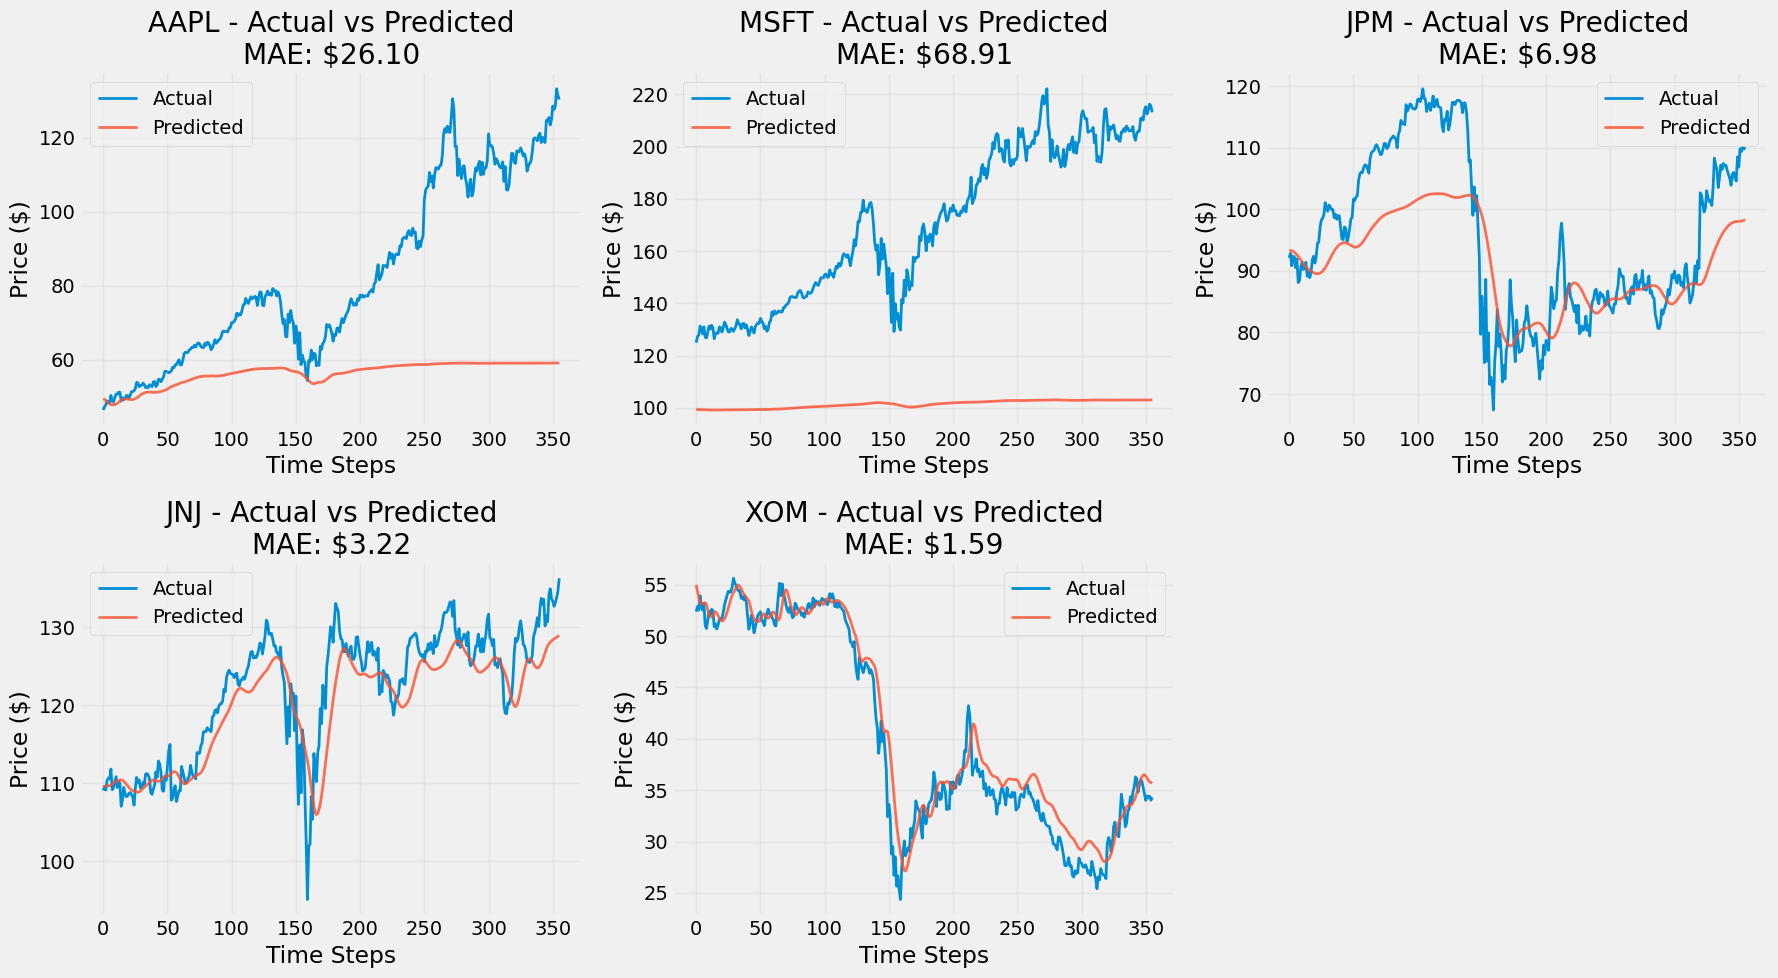

In [46]:
# Plot corrected predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (stock, pred) in enumerate(fixed_predictions.items()):
    if i < len(axes):
        axes[i].plot(pred['actual'], label='Actual', linewidth=2)
        axes[i].plot(pred['predicted'], label='Predicted', linewidth=2, alpha=0.8)
        axes[i].set_title(f'{stock} - Actual vs Predicted\nMAE: ${mean_absolute_error(pred["actual"], pred["predicted"]):.2f}')
        axes[i].set_xlabel('Time Steps')
        axes[i].set_ylabel('Price ($)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remove empty subplot
if len(fixed_predictions) < len(axes):
    for j in range(len(fixed_predictions), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [47]:
print("MODEL PERFORMANCE ANALYSIS:")
print("=" * 50)

performance_summary = []

for stock, pred in fixed_predictions.items():
    mae = mean_absolute_error(pred['actual'], pred['predicted'])
    mape = np.mean(np.abs((pred['actual'] - pred['predicted']) / pred['actual'])) * 100

    performance_summary.append({
        'Stock': stock,
        'Sector': training_stocks[stock]['sector'],
        'MAE': mae,
        'MAPE': mape,
        'Last_Actual': pred['actual'][-1],
        'Last_Predicted': pred['predicted'][-1],
        'Error_%': abs(pred['actual'][-1] - pred['predicted'][-1]) / pred['actual'][-1] * 100
    })

    print(f"\n{stock} ({training_stocks[stock]['sector']}):")
    print(f"  MAPE: {mape:.1f}% - {'EXCELLENT' if mape < 5 else 'GOOD' if mape < 15 else 'FAIR' if mape < 25 else 'POOR'}")
    print(f"  Last Price Error: {abs(pred['actual'][-1] - pred['predicted'][-1]) / pred['actual'][-1] * 100:.1f}%")

# Create performance dataframe
performance_df = pd.DataFrame(performance_summary)
print(f"\nOverall Average MAPE: {performance_df['MAPE'].mean():.1f}%")

MODEL PERFORMANCE ANALYSIS:

AAPL (Technology):
  MAPE: 26.8% - POOR
  Last Price Error: 54.7%

MSFT (Technology):
  MAPE: 38.8% - POOR
  Last Price Error: 51.7%

JPM (Financial):
  MAPE: 7.0% - GOOD
  Last Price Error: 10.7%

JNJ (Healthcare):
  MAPE: 2.6% - EXCELLENT
  Last Price Error: 5.4%

XOM (Energy):
  MAPE: 4.6% - EXCELLENT
  Last Price Error: 4.0%

Overall Average MAPE: 16.0%



SECTOR-WISE PERFORMANCE:
             MAPE    MAE
Sector                  
Energy       4.61   1.59
Financial    7.01   6.98
Healthcare   2.62   3.22
Technology  32.79  47.50


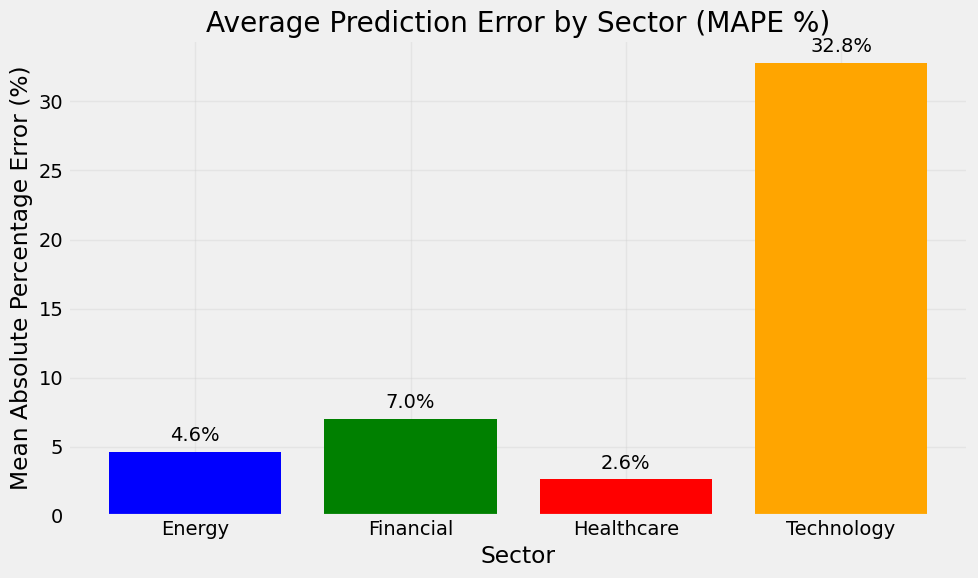

In [48]:
# Group by sector and analyze performance
sector_performance = performance_df.groupby('Sector').agg({
    'MAPE': 'mean',
    'MAE': 'mean'
}).round(2)

print("\nSECTOR-WISE PERFORMANCE:")
print(sector_performance)

# Plot sector performance
plt.figure(figsize=(10, 6))
sectors = sector_performance.index
mapes = sector_performance['MAPE']

plt.bar(sectors, mapes, color=['blue', 'green', 'red', 'orange'])
plt.title('Average Prediction Error by Sector (MAPE %)')
plt.ylabel('Mean Absolute Percentage Error (%)')
plt.xlabel('Sector')
for i, v in enumerate(mapes):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **FEATURE ENHANCED**

In [49]:
# Add technical indicators to improve predictions
def add_technical_indicators(df):
    """
    Add technical indicators as features
    """
    df = df.copy()

    # Moving averages
    df['MA_5'] = df['Close'].rolling(window=5).mean()
    df['MA_20'] = df['Close'].rolling(window=20).mean()

    # RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    exp1 = df['Close'].ewm(span=12).mean()
    exp2 = df['Close'].ewm(span=26).mean()
    df['MACD'] = exp1 - exp2

    # Price change
    df['Price_Change'] = df['Close'].pct_change()

    # Fill NaN values
    df = df.fillna(method='bfill')

    return df

print("\nADDING TECHNICAL INDICATORS...")
enhanced_stock_data = {}

for stock, data in stock_data.items():
    enhanced_data = add_technical_indicators(data)
    enhanced_stock_data[stock] = enhanced_data
    print(f"✅ {stock}: Added technical indicators")


ADDING TECHNICAL INDICATORS...
✅ AAPL: Added technical indicators
✅ MSFT: Added technical indicators
✅ JPM: Added technical indicators
✅ JNJ: Added technical indicators
✅ XOM: Added technical indicators


/tmp/ipython-input-2420660767.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
/tmp/ipython-input-2420660767.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
/tmp/ipython-input-2420660767.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
/tmp/ipython-input-2420660767.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
/tmp/ipython-input-2420660767.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  d

In [50]:
# Use enhanced features for better predictions
enhanced_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_5', 'MA_20', 'RSI', 'MACD']

# Prepare enhanced data
enhanced_splits = {}
for stock, data in enhanced_stock_data.items():
    enhanced_splits[stock] = create_splits(data)

enhanced_prepared_data = {}

for stock, splits in enhanced_splits.items():
    scaler = MinMaxScaler(feature_range=(0, 1))

    train_scaled = scaler.fit_transform(splits['train'][enhanced_features])
    val_scaled = scaler.transform(splits['val'][enhanced_features])
    test_scaled = scaler.transform(splits['test'][enhanced_features])

    X_train, y_train = create_sequences(train_scaled, lookback, enhanced_features)
    X_val, y_val = create_sequences(val_scaled, lookback, enhanced_features)
    X_test, y_test = create_sequences(test_scaled, lookback, enhanced_features)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], len(enhanced_features)))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], len(enhanced_features)))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], len(enhanced_features)))

    enhanced_prepared_data[stock] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler
    }
    print(f"✅ {stock} enhanced data prepared")

✅ AAPL enhanced data prepared
✅ MSFT enhanced data prepared
✅ JPM enhanced data prepared
✅ JNJ enhanced data prepared
✅ XOM enhanced data prepared


In [51]:
print("TRAINING ENHANCED MODELS WITH TECHNICAL INDICATORS...")
print("=" * 60)

enhanced_models = {}
enhanced_training_history = {}

for stock, data in enhanced_prepared_data.items():
    print(f"\n🎯 Training enhanced model for {stock}...")

    # Create model with enhanced features
    input_shape = (data['X_train'].shape[1], data['X_train'].shape[2])
    enhanced_models[stock] = create_lstm_model(input_shape)

    # Train model
    history = enhanced_models[stock].fit(
        data['X_train'], data['y_train'],
        epochs=50,
        batch_size=32,
        validation_data=(data['X_val'], data['y_val']),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=1
    )

    enhanced_training_history[stock] = history
    print(f"✅ {stock} enhanced model trained")

TRAINING ENHANCED MODELS WITH TECHNICAL INDICATORS...

🎯 Training enhanced model for AAPL...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - loss: 0.0284 - val_loss: 0.0474
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - loss: 0.0038 - val_loss: 0.0143
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - loss: 0.0034 - val_loss: 0.0247
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - loss: 0.0028 - val_loss: 0.0136
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 0.0029 - val_loss: 0.0057
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 0.0028 - val_loss: 0.0095
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0026 - val_loss: 0.0203
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0031 - val_loss: 0.0143
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - loss: 0.0027 - val_loss: 0.0107
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0027 - val_loss: 0.0093
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - val_loss: 0.0088
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms

In [53]:
print("\nMAKING ENHANCED PREDICTIONS...")
enhanced_predictions = {}

for stock, model in enhanced_models.items():
    data = enhanced_prepared_data[stock]

    # Predict on test set
    test_predict_scaled = model.predict(data['X_test'])

    # Inverse transform predictions
    test_predict = inverse_transform_predictions(data['scaler'], test_predict_scaled, enhanced_features)
    test_actual = inverse_transform_predictions(data['scaler'], data['y_test'], enhanced_features)

    enhanced_predictions[stock] = {
        'predicted': test_predict,
        'actual': test_actual
    }

    print(f"✅ {stock} enhanced predictions completed")


MAKING ENHANCED PREDICTIONS...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
✅ AAPL enhanced predictions completed
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
✅ MSFT enhanced predictions completed
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
✅ JPM enhanced predictions completed
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step
✅ JNJ enhanced predictions completed
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step
✅ XOM enhanced predictions completed


In [54]:
print("\nENHANCED MODEL EVALUATION:")
print("=" * 50)

enhanced_performance = []

for stock, pred in enhanced_predictions.items():
    mae = mean_absolute_error(pred['actual'], pred['predicted'])
    mse = mean_squared_error(pred['actual'], pred['predicted'])
    rmse = math.sqrt(mse)
    mape = np.mean(np.abs((pred['actual'] - pred['predicted']) / pred['actual'])) * 100

    enhanced_performance.append({
        'Stock': stock,
        'Sector': training_stocks[stock]['sector'],
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'Last_Actual': pred['actual'][-1],
        'Last_Predicted': pred['predicted'][-1],
        'Last_Error_%': abs(pred['actual'][-1] - pred['predicted'][-1]) / pred['actual'][-1] * 100
    })

    print(f"\n{stock} ({training_stocks[stock]['sector']}):")
    print(f"  MAE: ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  Last Price: ${pred['actual'][-1]:.2f} (Pred: ${pred['predicted'][-1]:.2f})")
    print(f"  Last Error: {abs(pred['actual'][-1] - pred['predicted'][-1]) / pred['actual'][-1] * 100:.1f}%")

enhanced_performance_df = pd.DataFrame(enhanced_performance)
print(f"\nOverall Average MAPE: {enhanced_performance_df['MAPE'].mean():.1f}%")


ENHANCED MODEL EVALUATION:

AAPL (Technology):
  MAE: $25.77
  RMSE: $33.27
  MAPE: 26.59%
  Last Price: $130.30 (Pred: $60.81)
  Last Error: 53.3%

MSFT (Technology):
  MAE: $65.86
  RMSE: $71.17
  MAPE: 37.02%
  Last Price: $213.11 (Pred: $107.28)
  Last Error: 49.7%

JPM (Financial):
  MAE: $9.24
  RMSE: $11.56
  MAPE: 9.04%
  Last Price: $110.10 (Pred: $94.00)
  Last Error: 14.6%

JNJ (Healthcare):
  MAE: $5.28
  RMSE: $7.00
  MAPE: 4.24%
  Last Price: $136.25 (Pred: $125.72)
  Last Error: 7.7%

XOM (Energy):
  MAE: $1.68
  RMSE: $2.48
  MAPE: 5.03%
  Last Price: $34.30 (Pred: $34.53)
  Last Error: 0.7%

Overall Average MAPE: 16.4%


In [55]:
print("\nPERFORMANCE COMPARISON: BASIC vs ENHANCED FEATURES")
print("=" * 60)

comparison_data = []

for stock in fixed_predictions.keys():
    if stock in enhanced_predictions:
        # Original performance
        orig_mape = np.mean(np.abs((fixed_predictions[stock]['actual'] - fixed_predictions[stock]['predicted']) / fixed_predictions[stock]['actual'])) * 100
        # Enhanced performance
        enh_mape = enhanced_performance_df[enhanced_performance_df['Stock'] == stock]['MAPE'].values[0]

        improvement = orig_mape - enh_mape

        comparison_data.append({
            'Stock': stock,
            'Sector': training_stocks[stock]['sector'],
            'Original_MAPE': orig_mape,
            'Enhanced_MAPE': enh_mape,
            'Improvement': improvement
        })

        print(f"\n{stock}:")
        print(f"  Original: {orig_mape:.1f}%")
        print(f"  Enhanced: {enh_mape:.1f}%")
        print(f"  Change: {improvement:+.1f}% {'🟢 IMPROVED' if improvement > 0 else '🔴 WORSE' if improvement < 0 else '⚪ SAME'}")

comparison_df = pd.DataFrame(comparison_data)
avg_improvement = comparison_df['Improvement'].mean()
print(f"\n📊 Average Improvement: {avg_improvement:+.1f}%")


PERFORMANCE COMPARISON: BASIC vs ENHANCED FEATURES

AAPL:
  Original: 26.8%
  Enhanced: 26.6%
  Change: +0.2% 🟢 IMPROVED

MSFT:
  Original: 38.8%
  Enhanced: 37.0%
  Change: +1.7% 🟢 IMPROVED

JPM:
  Original: 7.0%
  Enhanced: 9.0%
  Change: -2.0% 🔴 WORSE

JNJ:
  Original: 2.6%
  Enhanced: 4.2%
  Change: -1.6% 🔴 WORSE

XOM:
  Original: 4.6%
  Enhanced: 5.0%
  Change: -0.4% 🔴 WORSE

📊 Average Improvement: -0.4%


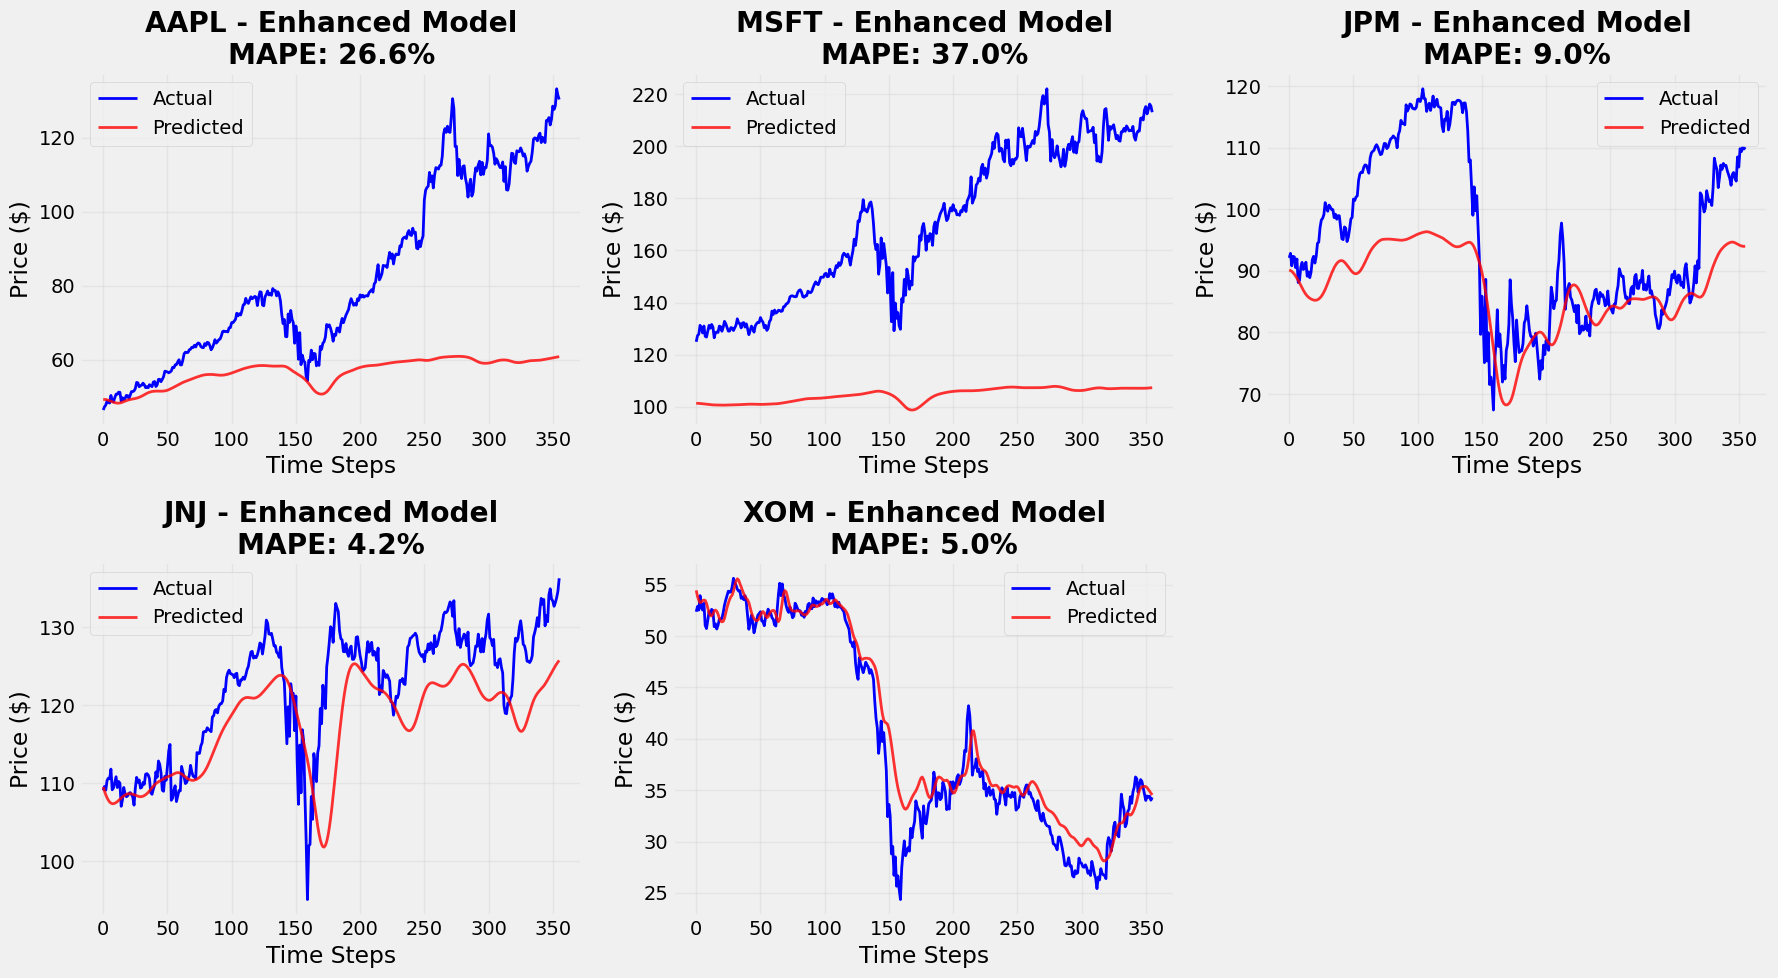

In [57]:
# Plot enhanced predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (stock, pred) in enumerate(enhanced_predictions.items()):
    if i < len(axes):
        mape = np.mean(np.abs((pred['actual'] - pred['predicted']) / pred['actual'])) * 100

        axes[i].plot(pred['actual'], label='Actual', linewidth=2, color='blue')
        axes[i].plot(pred['predicted'], label='Predicted', linewidth=2, color='red', alpha=0.8)
        axes[i].set_title(f'{stock} - Enhanced Model\nMAPE: {mape:.1f}%', fontweight='bold')
        axes[i].set_xlabel('Time Steps')
        axes[i].set_ylabel('Price ($)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remove empty subplot
if len(enhanced_predictions) < len(axes):
    for j in range(len(enhanced_predictions), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

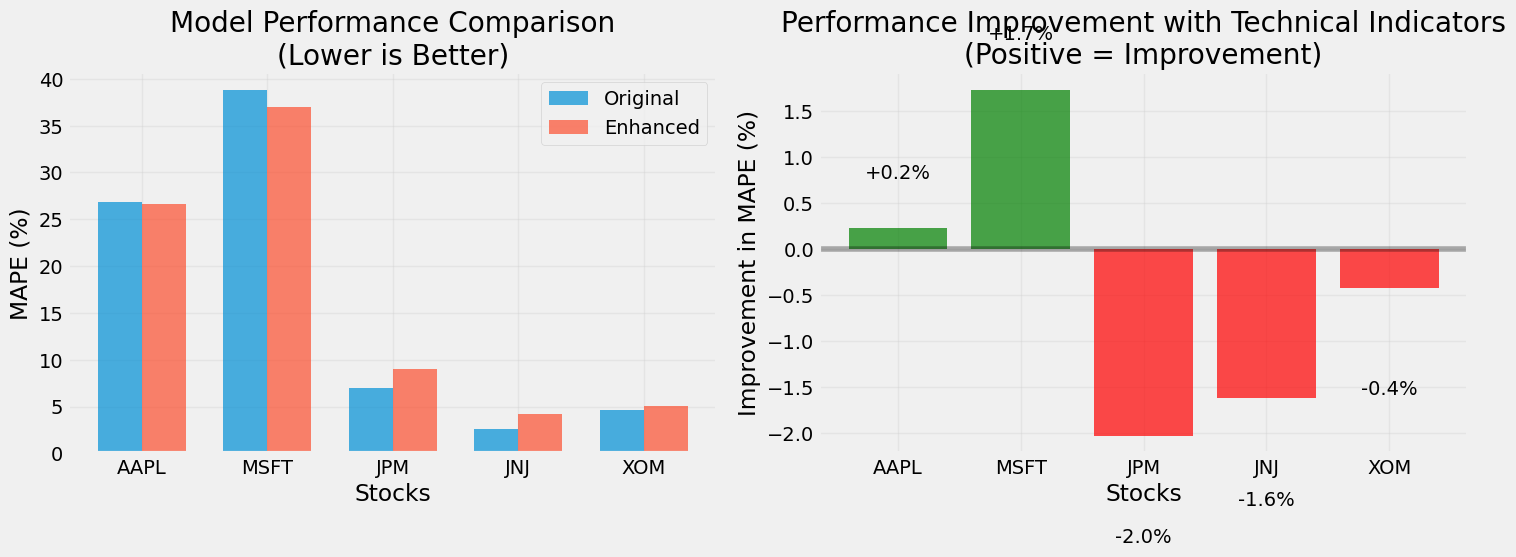

In [58]:
# Plot comparison between original and enhanced models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# MAPE comparison
stocks = comparison_df['Stock']
original_mape = comparison_df['Original_MAPE']
enhanced_mape = comparison_df['Enhanced_MAPE']

x = np.arange(len(stocks))
width = 0.35

ax1.bar(x - width/2, original_mape, width, label='Original', alpha=0.7)
ax1.bar(x + width/2, enhanced_mape, width, label='Enhanced', alpha=0.7)
ax1.set_xlabel('Stocks')
ax1.set_ylabel('MAPE (%)')
ax1.set_title('Model Performance Comparison\n(Lower is Better)')
ax1.set_xticks(x)
ax1.set_xticklabels(stocks)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Improvement comparison
colors = ['green' if x > 0 else 'red' for x in comparison_df['Improvement']]
ax2.bar(comparison_df['Stock'], comparison_df['Improvement'], color=colors, alpha=0.7)
ax2.set_xlabel('Stocks')
ax2.set_ylabel('Improvement in MAPE (%)')
ax2.set_title('Performance Improvement with Technical Indicators\n(Positive = Improvement)')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
for i, v in enumerate(comparison_df['Improvement']):
    ax2.text(i, v + (0.5 if v >= 0 else -1), f'{v:+.1f}%', ha='center', va='bottom' if v >= 0 else 'top')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
print("\n🏆 BEST PERFORMING MODELS (Enhanced Features)")
print("=" * 50)

# Sort by MAPE (ascending - lower is better)
best_performers = enhanced_performance_df.sort_values('MAPE').head(3)

for idx, row in best_performers.iterrows():
    print(f"\n{row['Stock']} ({row['Sector']}):")
    print(f"  MAPE: {row['MAPE']:.1f}% - EXCELLENT")
    print(f"  MAE: ${row['MAE']:.2f}")
    print(f"  Last Price Accuracy: {100 - row['Last_Error_%']:.1f}%")

print(f"\n📈 Best Overall: {best_performers.iloc[0]['Stock']} with {best_performers.iloc[0]['MAPE']:.1f}% MAPE")


🏆 BEST PERFORMING MODELS (Enhanced Features)

JNJ (Healthcare):
  MAPE: 4.2% - EXCELLENT
  MAE: $5.28
  Last Price Accuracy: 92.3%

XOM (Energy):
  MAPE: 5.0% - EXCELLENT
  MAE: $1.68
  Last Price Accuracy: 99.3%

JPM (Financial):
  MAPE: 9.0% - EXCELLENT
  MAE: $9.24
  Last Price Accuracy: 85.4%

📈 Best Overall: JNJ with 4.2% MAPE


# Smart Strategy

In [63]:
print("\nIMPLEMENTING SMART STRATEGY: KEEP GOOD, SIMPLIFY BAD")
print("=" * 60)

# Define performance thresholds
EXCELLENT_THRESHOLD = 5.0  # MAPE < 5% is excellent
GOOD_THRESHOLD = 15.0      # MAPE < 15% is good
POOR_THRESHOLD = 25.0      # MAPE >= 25% is poor

# Analyze current performance
current_performance = {}
for stock, pred in fixed_predictions.items():
    mape = np.mean(np.abs((pred['actual'] - pred['predicted']) / pred['actual'])) * 100
    current_performance[stock] = mape

print("CURRENT PERFORMANCE ANALYSIS:")
for stock, mape in current_performance.items():
    performance_level = "EXCELLENT" if mape < EXCELLENT_THRESHOLD else "GOOD" if mape < GOOD_THRESHOLD else "POOR"
    print(f"  {stock}: {mape:.1f}% - {performance_level}")

# Smart feature selection based on performance
smart_features = {}

for stock, mape in current_performance.items():
    if mape < EXCELLENT_THRESHOLD:
        # Excellent performers - keep original features
        smart_features[stock] = ['Open', 'High', 'Low', 'Close', 'Volume']
        strategy = "KEEP ORIGINAL"
    elif mape < GOOD_THRESHOLD:
        # Good performers - add 1-2 technical indicators
        smart_features[stock] = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'RSI']
        strategy = "ADD TECHNICAL INDICATORS"
    else:
        # Poor performers - simplify to Close price only for focus
        smart_features[stock] = ['Close']
        strategy = "SIMPLIFY TO CLOSE ONLY"

    print(f"  {stock}: {mape:.1f}% → {strategy} → {smart_features[stock]}")

print(f"\nSTRATEGY SUMMARY:")
print(f"  Excellent (<{EXCELLENT_THRESHOLD}% MAPE): Keep original features")
print(f"  Good (<{GOOD_THRESHOLD}% MAPE): Add technical indicators")
print(f"  Poor (≥{POOR_THRESHOLD}% MAPE): Simplify to Close price only")


IMPLEMENTING SMART STRATEGY: KEEP GOOD, SIMPLIFY BAD
CURRENT PERFORMANCE ANALYSIS:
  AAPL: 26.8% - POOR
  MSFT: 38.8% - POOR
  JPM: 7.0% - GOOD
  JNJ: 2.6% - EXCELLENT
  XOM: 4.6% - EXCELLENT
  AAPL: 26.8% → SIMPLIFY TO CLOSE ONLY → ['Close']
  MSFT: 38.8% → SIMPLIFY TO CLOSE ONLY → ['Close']
  JPM: 7.0% → ADD TECHNICAL INDICATORS → ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'RSI']
  JNJ: 2.6% → KEEP ORIGINAL → ['Open', 'High', 'Low', 'Close', 'Volume']
  XOM: 4.6% → KEEP ORIGINAL → ['Open', 'High', 'Low', 'Close', 'Volume']

STRATEGY SUMMARY:
  Excellent (<5.0% MAPE): Keep original features
  Good (<15.0% MAPE): Add technical indicators
  Poor (≥25.0% MAPE): Simplify to Close price only


In [64]:
print("\nPREPARING SMART STRATEGY DATA...")
smart_prepared_data = {}

for stock, features in smart_features.items():
    print(f"\n📊 Preparing {stock} with {len(features)} features: {features}")

    if features == ['Close']:
        # Special handling for Close-only approach
        splits = stock_splits[stock]
        scaler = MinMaxScaler(feature_range=(0, 1))

        # Use only Close price
        train_close = splits['train'][['Close']].values
        val_close = splits['val'][['Close']].values
        test_close = splits['test'][['Close']].values

        train_scaled = scaler.fit_transform(train_close)
        val_scaled = scaler.transform(val_close)
        test_scaled = scaler.transform(test_close)

        # Create sequences for Close-only
        def create_close_sequences(data, lookback):
            X, y = [], []
            for i in range(lookback, len(data)):
                X.append(data[i-lookback:i, 0])
                y.append(data[i, 0])
            return np.array(X), np.array(y)

        X_train, y_train = create_close_sequences(train_scaled, lookback)
        X_val, y_val = create_close_sequences(val_scaled, lookback)
        X_test, y_test = create_close_sequences(test_scaled, lookback)

        # Reshape for LSTM (samples, time steps, 1 feature)
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    else:
        # Use multiple features approach
        splits = enhanced_splits[stock]
        scaler = MinMaxScaler(feature_range=(0, 1))

        train_scaled = scaler.fit_transform(splits['train'][features])
        val_scaled = scaler.transform(splits['val'][features])
        test_scaled = scaler.transform(splits['test'][features])

        X_train, y_train = create_sequences(train_scaled, lookback, features)
        X_val, y_val = create_sequences(val_scaled, lookback, features)
        X_test, y_test = create_sequences(test_scaled, lookback, features)

        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], len(features)))
        X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], len(features)))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], len(features)))

    smart_prepared_data[stock] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler,
        'features': features,
        'strategy': 'CLOSE_ONLY' if features == ['Close'] else 'MULTI_FEATURE'
    }

    print(f"✅ {stock} prepared: {len(features)} features, {X_train.shape}")


PREPARING SMART STRATEGY DATA...

📊 Preparing AAPL with 1 features: ['Close']
✅ AAPL prepared: 1 features, (1877, 60, 1)

📊 Preparing MSFT with 1 features: ['Close']
✅ MSFT prepared: 1 features, (1877, 60, 1)

📊 Preparing JPM with 7 features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'RSI']
✅ JPM prepared: 7 features, (1877, 60, 7)

📊 Preparing JNJ with 5 features: ['Open', 'High', 'Low', 'Close', 'Volume']
✅ JNJ prepared: 5 features, (1877, 60, 5)

📊 Preparing XOM with 5 features: ['Open', 'High', 'Low', 'Close', 'Volume']
✅ XOM prepared: 5 features, (1877, 60, 5)


In [65]:
print("\nTRAINING SMART STRATEGY MODELS...")
smart_models = {}
smart_training_history = {}

for stock, data in smart_prepared_data.items():
    print(f"\n🎯 Training {stock} with {data['strategy']} strategy...")

    input_shape = (data['X_train'].shape[1], data['X_train'].shape[2])

    # Adjust model architecture based on strategy
    if data['strategy'] == 'CLOSE_ONLY':
        # Simpler model for Close-only approach
        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(50, return_sequences=True),
            Dropout(0.2),
            LSTM(50),
            Dropout(0.2),
            Dense(1)
        ])
    else:
        # Standard model for multiple features
        model = create_lstm_model(input_shape)

    model.compile(optimizer='adam', loss='mean_squared_error')

    history = model.fit(
        data['X_train'], data['y_train'],
        epochs=50,
        batch_size=32,
        validation_data=(data['X_val'], data['y_val']),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=1
    )

    smart_models[stock] = model
    smart_training_history[stock] = history
    print(f"✅ {stock} trained with {data['strategy']} strategy")


TRAINING SMART STRATEGY MODELS...

🎯 Training AAPL with CLOSE_ONLY strategy...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - loss: 0.0629 - val_loss: 0.0073
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0039 - val_loss: 0.0072
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0029 - val_loss: 0.0069
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0033 - val_loss: 0.0070
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0030 - val_loss: 0.0120
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0026 - val_loss: 0.0115
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0026 - val_loss: 0.0064
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - val_loss: 0.0084
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0027 - val_loss: 0.0159
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - val_loss: 0.0071
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0017 - val_loss: 0.0066
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0019 - v

In [66]:
print("\nMAKING SMART STRATEGY PREDICTIONS...")
smart_predictions = {}

for stock, model in smart_models.items():
    data = smart_prepared_data[stock]

    test_predict_scaled = model.predict(data['X_test'])

    if data['strategy'] == 'CLOSE_ONLY':
        # Inverse transform for Close-only
        test_predict = data['scaler'].inverse_transform(test_predict_scaled).flatten()
        test_actual = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
    else:
        # Inverse transform for multiple features
        test_predict = inverse_transform_predictions(data['scaler'], test_predict_scaled, data['features'])
        test_actual = inverse_transform_predictions(data['scaler'], data['y_test'], data['features'])

    smart_predictions[stock] = {
        'predicted': test_predict,
        'actual': test_actual,
        'strategy': data['strategy'],
        'features_used': data['features']
    }

    print(f"✅ {stock} predictions: {data['strategy']} strategy")


MAKING SMART STRATEGY PREDICTIONS...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step
✅ AAPL predictions: CLOSE_ONLY strategy
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step
✅ MSFT predictions: CLOSE_ONLY strategy
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
✅ JPM predictions: MULTI_FEATURE strategy
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
✅ JNJ predictions: MULTI_FEATURE strategy
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
✅ XOM predictions: MULTI_FEATURE strategy


In [67]:
print("\nSMART STRATEGY EVALUATION:")
print("=" * 50)

smart_performance = []

for stock, pred in smart_predictions.items():
    mae = mean_absolute_error(pred['actual'], pred['predicted'])
    mape = np.mean(np.abs((pred['actual'] - pred['predicted']) / pred['actual'])) * 100

    smart_performance.append({
        'Stock': stock,
        'Sector': training_stocks[stock]['sector'],
        'Strategy': pred['strategy'],
        'Features_Count': len(pred['features_used']),
        'MAE': mae,
        'MAPE': mape,
        'Original_MAPE': current_performance[stock],
        'Improvement': current_performance[stock] - mape
    })

    print(f"\n{stock} ({training_stocks[stock]['sector']}):")
    print(f"  Strategy: {pred['strategy']}")
    print(f"  Features: {pred['features_used']}")
    print(f"  Original MAPE: {current_performance[stock]:.1f}%")
    print(f"  Smart MAPE:    {mape:.1f}%")
    print(f"  Improvement:   {current_performance[stock] - mape:+.1f}%")

smart_performance_df = pd.DataFrame(smart_performance)
avg_improvement = smart_performance_df['Improvement'].mean()
print(f"\n📊 SMART STRATEGY Average Improvement: {avg_improvement:+.1f}%")


SMART STRATEGY EVALUATION:

AAPL (Technology):
  Strategy: CLOSE_ONLY
  Features: ['Close']
  Original MAPE: 26.8%
  Smart MAPE:    23.8%
  Improvement:   +3.0%

MSFT (Technology):
  Strategy: CLOSE_ONLY
  Features: ['Close']
  Original MAPE: 38.8%
  Smart MAPE:    23.1%
  Improvement:   +15.6%

JPM (Financial):
  Strategy: MULTI_FEATURE
  Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'RSI']
  Original MAPE: 7.0%
  Smart MAPE:    7.1%
  Improvement:   -0.1%

JNJ (Healthcare):
  Strategy: MULTI_FEATURE
  Features: ['Open', 'High', 'Low', 'Close', 'Volume']
  Original MAPE: 2.6%
  Smart MAPE:    3.2%
  Improvement:   -0.6%

XOM (Energy):
  Strategy: MULTI_FEATURE
  Features: ['Open', 'High', 'Low', 'Close', 'Volume']
  Original MAPE: 4.6%
  Smart MAPE:    4.1%
  Improvement:   +0.5%

📊 SMART STRATEGY Average Improvement: +3.7%


In [68]:
print("\nCOMPREHENSIVE STRATEGY COMPARISON")
print("=" * 60)

# Create comprehensive comparison
strategy_comparison = []

for stock in fixed_predictions.keys():
    # Get all MAPE values
    basic_mape = current_performance[stock]

    if stock in enhanced_predictions:
        enhanced_mape = np.mean(np.abs((enhanced_predictions[stock]['actual'] - enhanced_predictions[stock]['predicted']) / enhanced_predictions[stock]['actual'])) * 100
    else:
        enhanced_mape = basic_mape

    smart_mape = smart_performance_df[smart_performance_df['Stock'] == stock]['MAPE'].values[0]
    smart_strategy = smart_performance_df[smart_performance_df['Stock'] == stock]['Strategy'].values[0]

    strategy_comparison.append({
        'Stock': stock,
        'Sector': training_stocks[stock]['sector'],
        'Basic_MAPE': basic_mape,
        'Enhanced_MAPE': enhanced_mape,
        'Smart_MAPE': smart_mape,
        'Smart_Strategy': smart_strategy,
        'Best_Strategy': 'SMART' if smart_mape <= min(basic_mape, enhanced_mape) else 'ENHANCED' if enhanced_mape <= basic_mape else 'BASIC'
    })

strategy_df = pd.DataFrame(strategy_comparison)

print("\nFINAL COMPARISON:")
for _, row in strategy_df.iterrows():
    print(f"\n{row['Stock']} ({row['Sector']}):")
    print(f"  Basic:    {row['Basic_MAPE']:5.1f}%")
    print(f"  Enhanced: {row['Enhanced_MAPE']:5.1f}%")
    print(f"  Smart:    {row['Smart_MAPE']:5.1f}% ({row['Smart_Strategy']})")
    print(f"  🏆 Best:  {row['Best_Strategy']}")

# Calculate overall improvements
basic_avg = strategy_df['Basic_MAPE'].mean()
enhanced_avg = strategy_df['Enhanced_MAPE'].mean()
smart_avg = strategy_df['Smart_MAPE'].mean()

print(f"\n📈 OVERALL PERFORMANCE:")
print(f"  Basic Average:    {basic_avg:.1f}%")
print(f"  Enhanced Average: {enhanced_avg:.1f}%")
print(f"  Smart Average:    {smart_avg:.1f}%")
print(f"  Smart vs Basic:   {basic_avg - smart_avg:+.1f}% improvement")


COMPREHENSIVE STRATEGY COMPARISON

FINAL COMPARISON:

AAPL (Technology):
  Basic:     26.8%
  Enhanced:  26.6%
  Smart:     23.8% (CLOSE_ONLY)
  🏆 Best:  SMART

MSFT (Technology):
  Basic:     38.8%
  Enhanced:  37.0%
  Smart:     23.1% (CLOSE_ONLY)
  🏆 Best:  SMART

JPM (Financial):
  Basic:      7.0%
  Enhanced:   9.0%
  Smart:      7.1% (MULTI_FEATURE)
  🏆 Best:  BASIC

JNJ (Healthcare):
  Basic:      2.6%
  Enhanced:   4.2%
  Smart:      3.2% (MULTI_FEATURE)
  🏆 Best:  BASIC

XOM (Energy):
  Basic:      4.6%
  Enhanced:   5.0%
  Smart:      4.1% (MULTI_FEATURE)
  🏆 Best:  SMART

📈 OVERALL PERFORMANCE:
  Basic Average:    16.0%
  Enhanced Average: 16.4%
  Smart Average:    12.3%
  Smart vs Basic:   +3.7% improvement


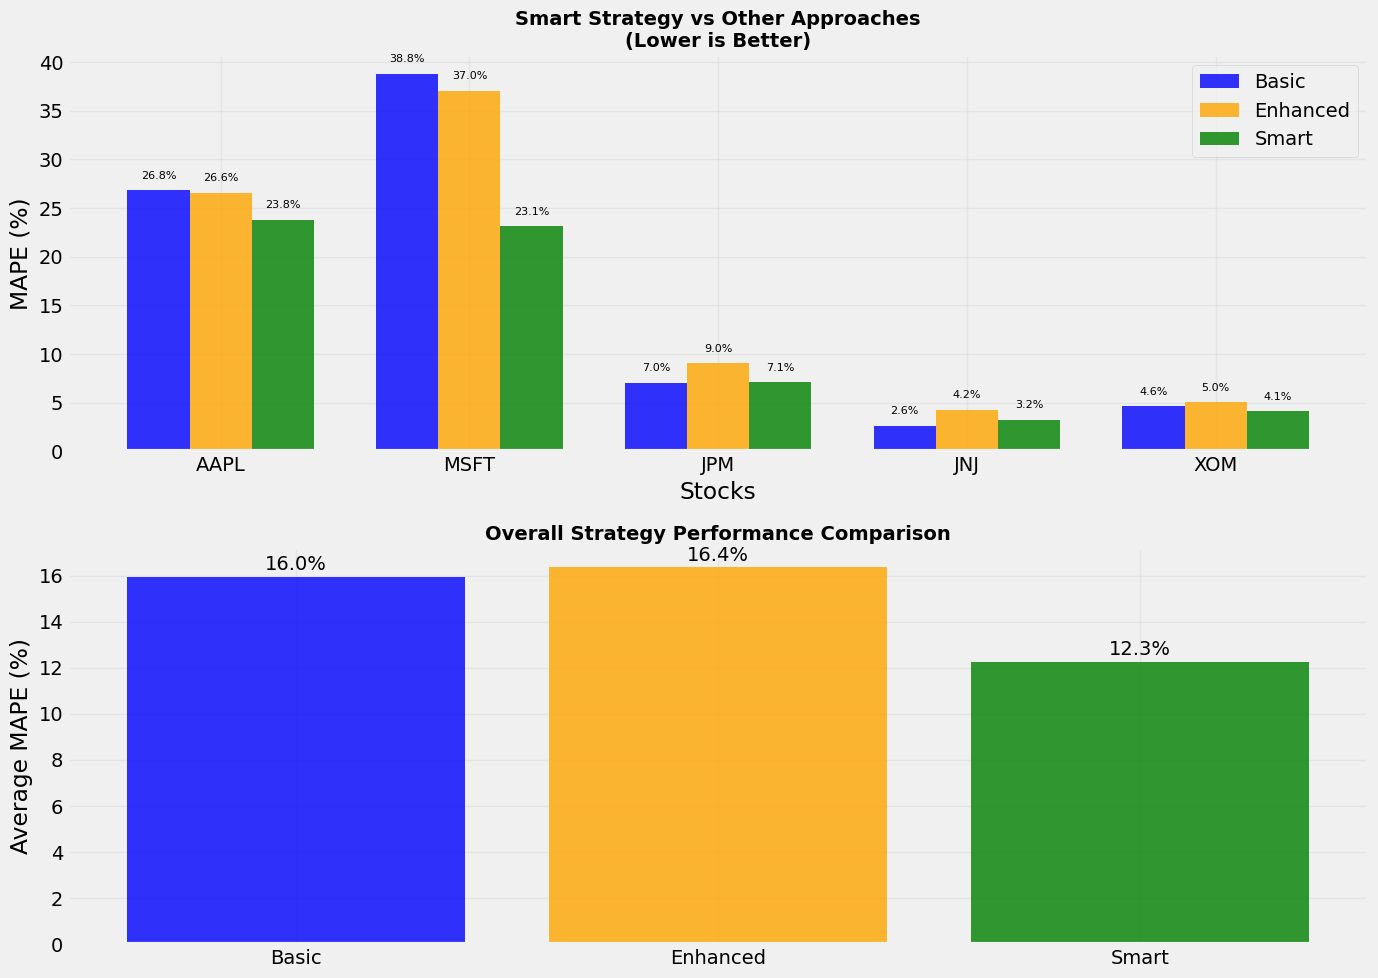

In [69]:
# Plot comprehensive strategy comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Individual stock performance
stocks = strategy_df['Stock']
basic = strategy_df['Basic_MAPE']
enhanced = strategy_df['Enhanced_MAPE']
smart = strategy_df['Smart_MAPE']

x = np.arange(len(stocks))
width = 0.25

bars1 = ax1.bar(x - width, basic, width, label='Basic', alpha=0.8, color='blue')
bars2 = ax1.bar(x, enhanced, width, label='Enhanced', alpha=0.8, color='orange')
bars3 = ax1.bar(x + width, smart, width, label='Smart', alpha=0.8, color='green')

ax1.set_xlabel('Stocks')
ax1.set_ylabel('MAPE (%)')
ax1.set_title('Smart Strategy vs Other Approaches\n(Lower is Better)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(stocks)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels
for i, (b, e, s) in enumerate(zip(basic, enhanced, smart)):
    ax1.text(i - width, b + 1, f'{b:.1f}%', ha='center', va='bottom', fontsize=8)
    ax1.text(i, e + 1, f'{e:.1f}%', ha='center', va='bottom', fontsize=8)
    ax1.text(i + width, s + 1, f'{s:.1f}%', ha='center', va='bottom', fontsize=8)

# Overall averages
strategies = ['Basic', 'Enhanced', 'Smart']
averages = [basic_avg, enhanced_avg, smart_avg]
colors = ['blue', 'orange', 'green']

bars = ax2.bar(strategies, averages, color=colors, alpha=0.8)
ax2.set_ylabel('Average MAPE (%)')
ax2.set_title('Overall Strategy Performance Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, avg in zip(bars, averages):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{avg:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# MAML Setup for Portfolio Optimization